In [1]:
import numpy as np
import pandas as pd
import plotly
import scipy
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as ply

In [2]:
df = pd.read_json("Master.json")
df.columns

Index(['session_key', 'driver_number', 'lap_number', 'date_start',
       'lap_duration', 'air_temperature', 'track_temperature', 'humidity',
       'rainfall', 'meeting_key', 'circuit_key', 'circuit_short_name',
       'session_name', 'session_type', 'circuit_curvature', 'circuit_length',
       'team_name', 'position', 'has_grid_position', 'stint_number',
       'compound', 'tyre_age'],
      dtype='str')

In [3]:
df.head()

,session_key,driver_number,lap_number,date_start,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,...,session_name,session_type,circuit_curvature,circuit_length,team_name,position,has_grid_position,stint_number,compound,tyre_age
0,7765,2,1,2023-03-03T11:30:07.574Z,NaN,27.400000,41.900000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Williams,0,False,1.0,HARD,0.0
1,7765,77,1,2023-03-03T11:30:09.215Z,129.966,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
2,7765,24,1,2023-03-03T11:30:14.011Z,140.357,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
3,7765,4,1,2023-03-03T11:30:16.168Z,128.935,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0
4,7765,81,1,2023-03-03T11:30:26.277Z,142.794,27.366667,41.833333,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0


In [4]:
df.dtypes

session_key             int64
driver_number           int64
lap_number              int64
date_start                str
lap_duration          float64
air_temperature       float64
track_temperature     float64
humidity              float64
rainfall              float64
meeting_key             int64
circuit_key             int64
circuit_short_name        str
session_name              str
session_type              str
circuit_curvature     float64
circuit_length        float64
team_name                 str
position                int64
has_grid_position        bool
stint_number          float64
compound                  str
tyre_age              float64
dtype: object

In [5]:
df = df.dropna().drop_duplicates()

In [6]:
df.head()

,session_key,driver_number,lap_number,date_start,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,...,session_name,session_type,circuit_curvature,circuit_length,team_name,position,has_grid_position,stint_number,compound,tyre_age
1,7765,77,1,2023-03-03T11:30:09.215Z,129.966,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
2,7765,24,1,2023-03-03T11:30:14.011Z,140.357,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
3,7765,4,1,2023-03-03T11:30:16.168Z,128.935,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0
4,7765,81,1,2023-03-03T11:30:26.277Z,142.794,27.366667,41.833333,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0
5,7765,21,1,2023-03-03T11:30:39.042Z,124.529,27.350000,41.800000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,AlphaTauri,0,False,1.0,MEDIUM,0.0


In [7]:
print(df["session_type"].value_counts(), "\n")
print(df["position"].value_counts())

session_type
Race          100678
Practice       80462
Qualifying     25279
Name: count, dtype: int64 

position
0     105741
14      5375
4       5324
13      5247
6       5224
7       5125
16      5067
17      5060
12      5056
5       5051
1       5024
10      5024
15      5018
2       5005
8       5001
3       4939
11      4895
9       4742
19      4648
18      4539
20      4304
21       565
22       445
Name: count, dtype: int64


> We see there is a class imbalance problem when it comes to positions. We must keep in mind that ALL practice sessions are labeled as position 0. They provide important lap-time information, but position information is moot for this data.

## Data preparation
* Conduct my data prep
* split X & y into 3 groups: regular (all sessions), non_practice (qualifying and racing), and racing
    * Allows for looking at per-group accuracies


In [8]:
# Drop unique identifiers and irrelevant data that introduce noise
to_drop = ["session_key", "meeting_key", "session_name", "circuit_short_name", "circuit_key", "date_start"]
df_cleaned = df.drop(columns=to_drop)

# onehot encode categorical variables
to_onehot = ["team_name", "driver_number", "session_type", "compound"]
df_cleaned = pd.get_dummies(df_cleaned, columns=to_onehot)

cutoff = df_cleaned["lap_duration"].quantile(0.93)
df_cleaned = df_cleaned[df_cleaned["lap_duration"] <= cutoff]

display(df_cleaned[["lap_duration"]].describe())
display(df_cleaned.info())

,lap_duration
count,191969.000000
mean,96.755886
std,20.795318
min,60.351000
25%,81.759000
50%,92.700000
75%,104.464000
max,181.678000


<class 'pandas.DataFrame'>
Index: 191969 entries, 1 to 228211
Data columns (total 88 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   lap_number                 191969 non-null  int64  
 1   lap_duration               191969 non-null  float64
 2   air_temperature            191969 non-null  float64
 3   track_temperature          191969 non-null  float64
 4   humidity                   191969 non-null  float64
 5   rainfall                   191969 non-null  float64
 6   circuit_curvature          191969 non-null  float64
 7   circuit_length             191969 non-null  float64
 8   position                   191969 non-null  int64  
 9   has_grid_position          191969 non-null  bool   
 10  stint_number               191969 non-null  float64
 11  tyre_age                   191969 non-null  float64
 12  team_name_Alfa Romeo       191969 non-null  bool   
 13  team_name_AlphaTauri       191969 non-null  b

None

Text(0.5, 0, 'Highest (absolute) pearson Correlation with lap_duration')

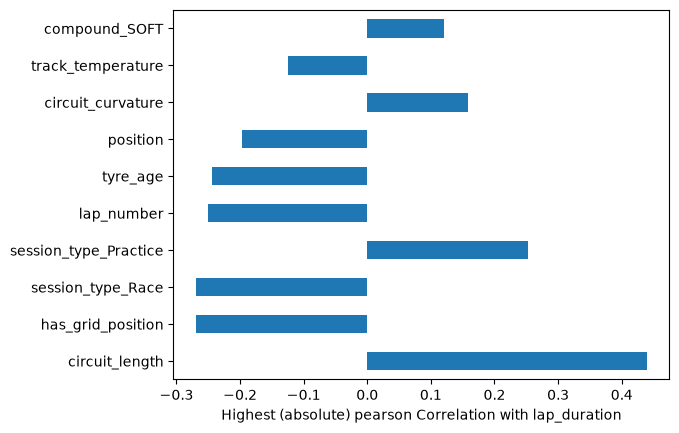

In [9]:
# Correlation Matrix of useless features
cor_mat = df_cleaned.corr()
col = "lap_duration"
# horizontal graph of the correlation matrix
import matplotlib.pyplot as plt

results = cor_mat[col].drop("lap_duration")

# show values along with the graph
plot = results.sort_values(key=abs, ascending=False).head(10).plot(kind="barh")
plt.xlabel("Highest (absolute) pearson Correlation with lap_duration")

Text(0.5, 0, 'Lowest (absolute) Pearson Correlation with lap_duration')

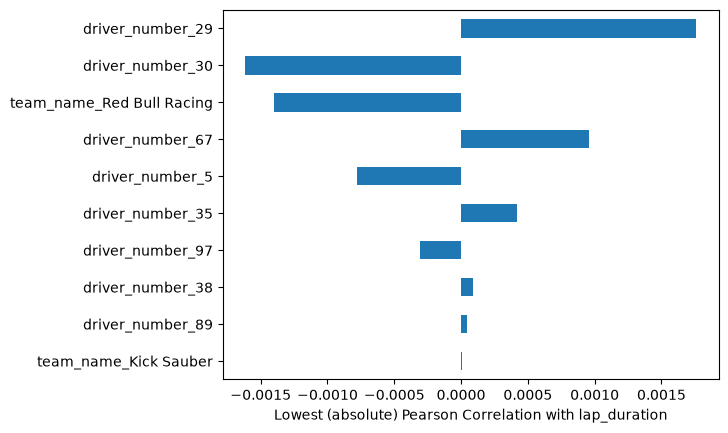

In [10]:
plot = results.sort_values(key=abs, ascending=True).head(10).plot(kind="barh")
plt.xlabel("Lowest (absolute) Pearson Correlation with lap_duration")

In [11]:
X = df_cleaned.drop(columns=["lap_duration"])
y = df_cleaned[["lap_duration", "session_type_Practice", "session_type_Race"]]

X_racing = X[X["session_type_Race"] == 1]
y_racing = y[y["session_type_Race"] == 1]

In [12]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.11, random_state=42, shuffle=True) # ~10% of the data is used for validation

In [13]:
# Create X and Y validation and test sets just for racing sessions (the most important)

X_val_racing = X_val[X_val["session_type_Race"] == 1]
y_val_racing = y_val[y_val["session_type_Race"] == 1]

X_test_racing = X_test[X_test["session_type_Race"] == 1]
y_test_racing = y_test[y_test["session_type_Race"] == 1]

# Remove the session_type_Practice column from Y features, as it is not the target variable
y_train = y_train.drop(columns=["session_type_Practice", "session_type_Race"])
y_val = y_val.drop(columns=["session_type_Practice", "session_type_Race"])
y_test = y_test.drop(columns=["session_type_Practice", "session_type_Race"])
y_val_racing = y_val_racing.drop(columns=["session_type_Practice", "session_type_Race"])
y_test_racing = y_test_racing.drop(columns=["session_type_Practice", "session_type_Race"])

In [14]:
## Racing version (temporray)
X_race_train, X_race_test, y_race_train, y_race_test = train_test_split(X_racing, y_racing, test_size=0.1, random_state=42, shuffle=True)
X_race_train, X_race_val, y_race_train, y_race_val = train_test_split(X_race_train, y_race_train, test_size=0.11, random_state=42, shuffle=True) # ~10% of the data is used for validation

y_race_train = y_race_train.drop(columns=["session_type_Practice", "session_type_Race"])
y_race_val = y_race_val.drop(columns=["session_type_Practice", "session_type_Race"])
y_race_test = y_race_test.drop(columns=["session_type_Practice", "session_type_Race"])

In [15]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf_model.fit(X_train, y_train)

c:\Users\gabri\Documents\Skool\F1-Grand-Prix-Predictor\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [16]:
rf_race_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf_race_model.fit(X_race_train, y_race_train)

c:\Users\gabri\Documents\Skool\F1-Grand-Prix-Predictor\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [17]:
## Racing version metrics

rf_race_preds1 = rf_race_model.predict(X_race_val)
rf_val_score = mean_absolute_error(y_race_val, rf_race_preds1)

rf_race_preds2 = rf_race_model.predict(X_race_test)
rf_test_score = mean_absolute_error(y_race_test, rf_race_preds2)

print(f"Random Forest Validation MAE: {rf_val_score:.4f}")
print(f"Random Forest Testing MAE: {rf_test_score:.4f}")


Random Forest Validation MAE: 0.8779
Random Forest Testing MAE: 0.8599


In [18]:
# Validation scores | can't do accuracy due to multi-output
rf_preds = rf_model.predict(X_val)
rf_score = mean_absolute_error(y_val, rf_preds)

# Racing validation scores
rf_preds_racing = rf_model.predict(X_val_racing)
rf_score_racing = mean_absolute_error(y_val_racing, rf_preds_racing)

print(f"Random Forest Validation MAE: {rf_score:.4f}")
print(f"Random Forest Validation MAE (racing sessions): {rf_score_racing:.4f}")


Random Forest Validation MAE: 5.7043
Random Forest Validation MAE (racing sessions): 0.9302


In [19]:
# test scores

rf_test_preds = rf_model.predict(X_test)
rf_test_mae = mean_absolute_error(y_test, rf_test_preds)

# racing test scores
rf_test_preds_racing = rf_model.predict(X_test_racing)
rf_test_mae_racing = mean_absolute_error(y_test_racing, rf_test_preds_racing)

print("====Test Accuracies====")
print(f"Random Forest Test MAE: {rf_test_mae:.4f}")
print(f"Random Forest Racing MAE: {rf_test_mae_racing:.4f}")

====Test Accuracies====
Random Forest Test MAE: 5.8003
Random Forest Racing MAE: 0.9440


## Cross Validation

In [21]:
# Cross validation with GridSearchCV

# Due to computational limitations, 2 values per param
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator = rf_race_model, 
    param_grid = param_grid,
    cv = 5,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1 # Use as many cores as available
)

grid_search.fit(X_race_train, y_race_train)


print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# best model params
best_rf = grid_search.best_estimator_
best_rf

c:\Users\gabri\Documents\Skool\F1-Grand-Prix-Predictor\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: -0.9930


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [24]:
best_rf_val_preds = best_rf.predict(X_race_val)
best_rf_val_mae = mean_absolute_error(y_race_val, best_rf_val_preds)

best_rf_test_preds = best_rf.predict(X_race_test)
best_rf_test_mae = mean_absolute_error(y_race_test, best_rf_test_preds)

print(f"Best RF (tuned) Validation MAE: {best_rf_val_mae:.4f}")
print(f"Best RF (tuned) Test MAE: {best_rf_test_mae:.4f}")

Best RF (tuned) Validation MAE: 0.8745
Best RF (tuned) Test MAE: 0.8574
